In [13]:
# === Imports ===
import struct
import os
import math
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.font_manager import FontProperties
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1 import make_axes_locatable

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from scipy.io import loadmat
from scipy.integrate import solve_ivp, odeint
from scipy.linalg import eig, svd, pinv
from scipy.stats import gaussian_kde, pearsonr, kurtosis
from scipy.interpolate import interp1d

import pysindy as ps
from pysindy import SINDy
from pysindy.feature_library import CustomLibrary
from pysindy.differentiation import FiniteDifference
from sindy_utils import *

import mpld3
%matplotlib inline
mpld3.enable_notebook()

# === Plot style configuration ===
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()
plt.rcParams.update({
    'axes.labelsize': 15,
    'axes.linewidth': 1.0,
    'font.size': 11,
    'legend.fontsize': 12,
})

# === Constants ===
Lx = 1024
Ly = 1024
center_x = Lx / 2
center_y = Ly / 2


# =============================================================================
# Utility functions
# =============================================================================

def moving_average(data, window_size):
    """Compute moving average for a 1-D array."""
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')


def moving_average_matrix(list_of_lists, window_size):
    """Compute moving average for each list in a list of lists."""
    result = []
    for lst in list_of_lists:
        moving_avg = []
        for i in range(len(lst) - window_size + 1):
            window = lst[i:i + window_size]
            avg = sum(window) / window_size
            moving_avg.append(avg)
        result.append(moving_avg)
    return result


def save_floats_to_file(float_list, filename):
    with open(filename, 'w') as file:
        for num in float_list:
            file.write(f"{num}\n")


def save_array_to_txt(array, filename):
    np.savetxt(filename, array, fmt='%.6f')


def save_names_to_txt(array, filename):
    np.savetxt(filename, array, fmt='%s')


def index_of_lowest_non_nan(input_list):
    """Return index of the minimum non-NaN value."""
    non_nan_values = [(i, x) for i, x in enumerate(input_list) if not math.isnan(x)]
    if not non_nan_values:
        return None
    min_index, _ = min(non_nan_values, key=lambda item: item[1])
    return min_index


def format_func(value, tick_number):
    N = int(np.round(value / np.pi))
    if N == 0:
        return "0"
    elif N == 1:
        return r"$\pi$"
    elif N == -1:
        return r"-$\pi$"
    else:
        return r"${0}\pi$".format(N)


# =============================================================================
# Binary file I/O and coordinate processing
# =============================================================================

def read_binary_file(file_path):
    data = []
    try:
        with open(file_path, 'rb') as file:
            while True:
                bytes_read = file.read(4)
                if not bytes_read:
                    break
                number = struct.unpack('f', bytes_read)[0]
                data.append(number)
    except Exception as e:
        print(f"Error reading file: {e}")
    return data


def save_coords_to_file(file_path, x_coords, y_coords):
    try:
        with open(file_path, 'w') as file:
            for x, y in zip(x_coords, y_coords):
                file.write(f"{x} {y}\n")
    except Exception as e:
        print(f"Error writing to file: {e}")


def read_coords_from_file(file_path):
    x_coords, y_coords = [], []
    try:
        with open(file_path, 'r') as file:
            for line in file:
                x, y = map(int, line.strip().split())
                x_coords.append(x)
                y_coords.append(y)
    except Exception as e:
        print(f"Error reading file: {e}")
    return np.array(x_coords), np.array(y_coords)


def reconstruct_arrays_from_files(output_folder):
    x_coords_over_time, y_coords_over_time = [], []
    files = sorted([f for f in os.listdir(output_folder)
                    if f.startswith("coords_") and f.endswith(".txt")])
    for filename in files:
        file_path = os.path.join(output_folder, filename)
        x_coords, y_coords = read_coords_from_file(file_path)
        x_coords_over_time.append(x_coords)
        y_coords_over_time.append(y_coords)
    return x_coords_over_time, y_coords_over_time


def process_files(input_folder, output_folder, output_folder2):
    from skimage import feature
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    files = sorted([f for f in os.listdir(input_folder) if f.startswith("phi.")])
    x_coords_over_time, y_coords_over_time = [], []
    print(len(files))
    for ind, filename in enumerate(files[10074:]):
        ind = ind + 10074
        file_path = os.path.join(input_folder, filename)
        numerical_data = read_binary_file(file_path)
        required_size = 1024 * 1024 * 2
        if len(numerical_data) != required_size:
            raise ValueError(
                f"Data size mismatch in file {filename}. "
                f"Expected {required_size}, got {len(numerical_data)}."
            )
        matrix = np.array(numerical_data).reshape((1024, 1024, 2))
        edges = feature.canny(matrix[:, :, 1])
        y_coords, x_coords = np.where(edges)
        x_coords_over_time.append(x_coords)
        y_coords_over_time.append(y_coords)
        coords_file_path = os.path.join(
            output_folder2, filename.replace("phi.", "coords_") + ".txt"
        )
        save_coords_to_file(coords_file_path, x_coords, y_coords)
        plt.imshow(edges, cmap='gray')
    return x_coords_over_time, y_coords_over_time


# =============================================================================
# Periodic boundary handling
# =============================================================================

def shift_coordinates_periodically(x_list, y_list, Lx, Ly):
    x_list_shift, y_list_shift = [], []
    for x, y in zip(x_list, y_list):
        if abs(x - x_list[0]) > Lx / 2:
            x = x - Lx if x > x_list[0] else x + Lx
        if abs(y - y_list[0]) > Ly / 2:
            y = y - Ly if y > y_list[0] else y + Ly
        x_list_shift.append(x)
        y_list_shift.append(y)
    return x_list_shift, y_list_shift


def apply_periodic_boundary(value, limit):
    if value < 0:
        return value + limit
    elif value >= limit:
        return value - limit
    return value


def deal_with_periodic(reconstructed_x_coords, reconstructed_y_coords, N):
    x_all_list, y_all_list = [], []

    for n in range(len(reconstructed_x_coords)):
        x_list_shift = reconstructed_x_coords[n]
        y_list_shift = reconstructed_y_coords[n]
        x_coords, y_coords = shift_coordinates_periodically(
            x_list_shift, y_list_shift, Lx, Ly
        )

        cx = np.mean(x_coords)
        cy = np.mean(y_coords)
        points = np.array(list(zip(x_coords, y_coords)))

        if len(points) >= 1:
            distances = np.sqrt((points[:, 0] - cx)**2 + (points[:, 1] - cy)**2)
            angles = np.arctan2(points[:, 1] - cy, points[:, 0] - cx)
            discretized_angles = np.linspace(-np.pi, np.pi, N, endpoint=False)

            filtered_points = []
            prev_point = None
            for angle in discretized_angles:
                tolerance = (np.pi / N) + 0.005
                mask = (angles >= angle - tolerance) & (angles < angle + tolerance)
                if np.any(mask):
                    selected_points = points[mask]
                    selected_distances = distances[mask]
                    max_idx = np.argmax(selected_distances)
                    filtered_points.append(selected_points[max_idx])
                    prev_point = selected_points[max_idx]
                elif prev_point is not None:
                    filtered_points.append(prev_point)

            filtered_points = [tuple(p) for p in filtered_points]
            x_all_list.append([p[0] for p in filtered_points])
            y_all_list.append([p[1] for p in filtered_points])

    return x_all_list, y_all_list


# =============================================================================
# Fourier truncation
# =============================================================================

def fourier_lowest_modes_matrix(signal_matrix, num_modes=None, freq_threshold=None):
    """
    Apply Fourier truncation to each column of a matrix, keeping lowest frequency modes.
    """
    num_time_points, num_signals = signal_matrix.shape
    truncated_matrix = np.zeros_like(signal_matrix)
    truncated_ffts = np.zeros((num_time_points, num_signals), dtype=complex)

    for i in range(num_signals):
        signal = signal_matrix[:, i]
        fft_values = np.fft.fft(signal)
        freqs = np.fft.fftfreq(num_time_points)

        if num_modes is not None:
            sorted_indices = np.argsort(np.abs(freqs))
            keep_indices = sorted_indices[:num_modes]
        elif freq_threshold is not None:
            keep_indices = np.where(np.abs(freqs) <= freq_threshold)[0]
        else:
            raise ValueError("Either num_modes or freq_threshold must be specified")

        truncated_fft = np.zeros_like(fft_values, dtype=complex)
        truncated_fft[keep_indices] = fft_values[keep_indices]
        truncated_ffts[:, i] = truncated_fft
        truncated_matrix[:, i] = np.fft.ifft(truncated_fft).real

    return truncated_matrix, truncated_ffts


def plot_results(original_signal, reconstructed_signal, fft_values, truncated_fft):
    """Plot original vs reconstructed signal and frequency spectra."""
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    plt.plot(original_signal, label='Original Signal')
    plt.plot(reconstructed_signal, '--', label='Reconstructed Signal')
    plt.title('Time Domain')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(np.abs(fft_values), label='Original FFT')
    plt.plot(np.abs(truncated_fft), '--', label='Truncated FFT')
    plt.title('Frequency Domain')
    plt.xlabel('Frequency Bin')
    plt.ylabel('Magnitude')
    plt.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# POD / DMD
# =============================================================================

def inner_product(Q, R):
    Qr = np.zeros(np.shape(Q))
    for i in range(np.shape(Q)[1]):
        Qr[:, i] = Q[:, i] * np.sqrt(R)
    return np.transpose(Qr) @ Qr


def vector_POD(inner_prod, t_train, r):
    S2, v = eig(inner_prod)
    idx = S2.argsort()[::-1]
    S2 = S2[idx]
    v = v[:, idx]
    Vh = np.transpose(v)

    print("% field in first r modes =",
          sum(np.sqrt(S2[0:r])) / sum(np.sqrt(S2)))
    print("% energy in first r modes =", sum(S2[0:r]) / sum(S2))

    S2 = np.diag(S2)
    vh = np.zeros((r, np.shape(Vh)[1]))
    feature_names = []
    for i in range(r):
        vh[i, :] = Vh[i, :] / sum(np.amax(abs(Vh), axis=1)[0:r])
        feature_names.append(r'$\varphi_{:d}$'.format(i + 1))
    x = np.transpose(vh)
    return x, feature_names, S2, Vh


def reconstruct_H(eigenvalues, modes, initial_condition, timesteps):
    """Reconstruct height data from DMD model."""
    omega = np.log(eigenvalues)
    H_recon = np.zeros((modes.shape[0], len(timesteps)), dtype=complex)
    amplitudes = pinv(modes) @ initial_condition
    for i, t in enumerate(timesteps):
        H_recon[:, i] = modes @ (amplitudes * np.exp(omega * t))
    return H_recon.real


# =============================================================================
# Height field
# =============================================================================

def find_height_field(x_all_list, y_all_list, N):
    h_store, t = [], []
    for ti in range(len(x_all_list)):
        if len(x_all_list[ti]) >= N:
            t.append(ti)
            x_cm = np.mean(x_all_list[ti])
            y_cm = np.mean(y_all_list[ti])
            h_list = [
                np.sqrt((x_all_list[ti][i] - x_cm)**2 + (y_all_list[ti][i] - y_cm)**2)
                for i in range(len(x_all_list[ti]))
            ]
            h_store.append(h_list)

    u = np.array(h_store).T
    time_averaged_h = np.mean(u, axis=1)
    u_sub = h_store - np.array(time_averaged_h)
    max_height = max(max(h) for h in u_sub)
    thetas = np.linspace(0, 2 * np.pi, len(u_sub[0]))

    dt = 2e-4
    ti = np.array(t)
    Tmax = dt * len(ti)
    print(Tmax)
    t = np.linspace(0, Tmax, len(ti))
    return u_sub, t, thetas, max_height


# =============================================================================
# Deformation / perimeter analysis
# =============================================================================

def calculate_perimeter(radius, angles):
    radius = np.array(radius)
    angles = np.array(angles)
    delta_r = np.diff(radius)
    delta_theta = np.diff(angles)
    ds = np.sqrt(delta_r**2 + (radius[:-1] * delta_theta)**2)
    return np.sum(ds)


def calc_deformation(Q_sim, Q_real, n_steps=1200, offset_correct=True):
    """
    Compute deformation parameter Gamma from simulated and real height fields.

    Returns: x_range, kde_original_vals, kde_predict_vals,
             error_mae, kl_divergence, error_kde_mse,
             gam_original, gam_predict
    """
    thetas = np.linspace(0, 2 * np.pi, 150)
    mismatch = (Q_sim[:, 0] - Q_real[:, 0]) if offset_correct else 0

    perimeter_data, perimeter_predict = [], []
    perimeter0_data, perimeter0_predict = [], []

    for i in range(n_steps):
        sim_plot = Q_sim[:, i] - mismatch
        real_plot = Q_real[:, i]

        perimeter_data.append(calculate_perimeter(real_plot, thetas))
        perimeter_predict.append(calculate_perimeter(sim_plot, thetas))

        perimeter0_data.append(np.abs(np.trapz(real_plot, thetas)))
        perimeter0_predict.append(np.abs(np.trapz(sim_plot, thetas)))

    gam_original = (np.array(perimeter_data) / np.array(perimeter0_data)) - 1
    gam_predict = (np.array(perimeter_predict) / np.array(perimeter0_predict)) - 1

    kde_original = gaussian_kde(gam_original)
    kde_predict = gaussian_kde(gam_predict)
    x_range = np.linspace(-0.5, 0.5, 1000)
    kde_original_vals = kde_original(x_range)
    kde_predict_vals = kde_predict(x_range)

    error_mae = np.mean(np.abs(gam_original - gam_predict))

    epsilon = 1e-10
    kde_orig_norm = (kde_original_vals + epsilon)
    kde_pred_norm = (kde_predict_vals + epsilon)
    kde_orig_norm = kde_orig_norm / np.sum(kde_orig_norm)
    kde_pred_norm = kde_pred_norm / np.sum(kde_pred_norm)
    kl_divergence = np.sum(kde_orig_norm * np.log(kde_orig_norm / kde_pred_norm))

    error_kde_mse = np.mean((kde_original_vals - kde_predict_vals)**2)

    return (x_range, kde_original_vals, kde_predict_vals,
            error_mae, kl_divergence, error_kde_mse,
            gam_original, gam_predict)


# =============================================================================
# Interpolation-based mode reduction
# =============================================================================

def reduce_x_order(x, gap):
    n_modes = x.shape[1]
    x_new = []
    for i in range(n_modes):
        y_data = x[:, i]
        x_points1 = range(0, len(y_data), gap)
        y_data_sampled = [
            sum(y_data[j:j + gap]) / len(y_data[j:j + gap]) for j in x_points1
        ]
        f_data = interp1d(x_points1, y_data_sampled, kind='cubic', fill_value='extrapolate')
        x_dense = np.linspace(min(x_points1), max(x_points1), len(x[:, i]))
        x_new.append(f_data(x_dense))
    return np.array(x_new).T


# =============================================================================
# SINDy model fitting and evaluation
# =============================================================================

def plot_x_fits(x_test, t_test, optimizer, n_models, r, model):
    dt = 2e-4
    pod_names = ["a{}".format(i) for i in range(1, r + 1)]
    model_x_store, model_coeff_store, model_term_store = [], [], []
    MSE_list = []

    plt.figure(figsize=(10, 5))
    gs = gridspec.GridSpec(r, n_models)
    gs.update(wspace=0.0, hspace=0.0)

    for j in range(n_models):
        model.print()
        model_coeff_store.append(model.coefficients())
        model_term_store.append(model.get_feature_names())
        optimizer.coef_ = np.asarray(optimizer.history_)[j, :, :]

        x_test_sim = model.simulate(x_test[0, :], t_test, integrator='odeint')
        model_x_store.append(x_test_sim)

        if j % 5 == 0:
            for i in range(r):
                plt.subplot(gs[i, j])
                x_test_plot = x_test[10:, i] / np.max(x_test[10:, i])
                x_sim_plot = x_test_sim[10:, i] / np.max(x_test_sim[10:, i])
                plt.plot(t_test[10:], x_test_plot, 'k', label='test trajectory')
                plt.plot(t_test[10:], x_sim_plot, 'r', label='model prediction')
                if j == 0:
                    plt.ylabel(pod_names[i], fontsize=20)
                if i == 0:
                    plt.title('MSE = %.0f' % model.score(
                        x_test, t=dt, metric=mean_squared_error), fontsize=16)
                plt.xlabel('Iteration ' + str(j), fontsize=16)
                ax = plt.gca()
                ax.set_xticklabels([])
                ax.set_yticklabels([])
                plt.grid(True)

        print('Model %d, MSE: %f' % (j, model.score(x_test, t=dt, metric=mean_squared_error)))
        MSE_list.append(model.score(x_test, t=dt, metric=mean_squared_error))

    plt.show()
    return model_x_store, MSE_list, model_coeff_store, model_term_store


def compressible_Framework(inner_prod, time, threshold, order, choose_model,
                           r, tfac, t_init, reduce):
    dt = 2e-4
    M_train = int(len(time) * tfac)
    t_train = time[:M_train]
    t_test = time[M_train:]
    print("t_test_check1:", len(t_test))

    x, feature_names, S2, Vh = vector_POD(inner_prod, time, r)
    xt = x
    print("X_trunc_SHAPE", xt.shape)

    x_train = xt[:M_train, :]
    x_test = xt[M_train:, :]
    x_true = xt[M_train:, :]

    polynomial_library = ps.PolynomialLibrary(degree=order)
    ssr_optimizer = ps.SSR(criteria="model_residual")
    model = ps.SINDy(feature_library=polynomial_library, optimizer=ssr_optimizer)
    model.fit(x_train, t=2e-5)

    n_models = 5
    print(f"Number of models in optimizer history: {n_models}")

    x_sim_list, MSE, model_coeff_store, model_term_store = plot_x_fits(
        x_test, t_test, ssr_optimizer, n_models, r, model
    )
    print(MSE)

    x_sim = x_sim_list[choose_model]
    coeff = model_coeff_store[choose_model]
    feature_names = model_term_store[choose_model]

    for i in range(r):
        scale = sum(np.amax(abs(Vh), axis=1)[0:r])
        x_sim[t_init:, i] = x_sim[t_init:, i] * scale / np.max(x_sim[t_init:, i])
        x_true[t_init:, i] = x_true[t_init:, i] * scale / np.max(x_true[t_init:, i])

    return (t_test, x_true[t_init:, :], x_train, x_sim[t_init:, :],
            S2, coeff, feature_names, MSE[choose_model])


def find_model(u_sub, thetas, ti, order, r, max_height,
               T_sim, t_sim_display, choose_model, lam, reduce):
    T_train = 8000
    T_tot = T_train + T_sim
    tfac = T_train / T_tot
    dt = reduce * 2e-4

    print("training set:", T_tot - T_sim)
    tf = ti + T_tot
    Tf_units = tf * dt
    Ti_units = ti * dt

    u = np.array(u_sub).T[:, ti:tf]
    t = np.arange(Ti_units, Tf_units, dt)
    print("lent", len(t))

    ip = inner_product(u, thetas)
    x, feature_names, S2, Vh = vector_POD(ip, t, 11)
    print("Xshape_trunc", x.shape)

    t_test, x_true, x_train, x_sim, S2, coefficients, feature_names, MSE_i = \
        compressible_Framework(ip, t, 0.04, order, choose_model,
                               r=r, tfac=tfac, t_init=t_sim_display, reduce=reduce)

    save_array_to_txt(x_true, f"coupled_data/{lam}_time_modes_true2")
    save_array_to_txt(x_sim, f"coupled_data/{lam}_time_modes_sim2")
    print("Xsim shape", x_sim.shape)
    print("Xtrue shape", x_true.shape)
    print('Done with SINDy')

    Q = u
    Vh_true = np.transpose(x_true)
    Vh_sim = np.transpose(x_sim)

    Sr = np.sqrt(S2[0:r, 0:r])
    w, v = eig(ip)
    Vh = np.transpose(v).real
    wr = np.sqrt(np.diag(w))

    U = Q @ (np.transpose(Vh)[:, :2 * r] @ (np.linalg.inv(wr)[:2 * r, :r]).real)
    U_true = U[:, 0:r]

    Q_sim = (U_true @ wr[0:r, 0:r] @ Vh_sim).real
    Q_real = (U_true @ wr[0:r, 0:r] @ Vh_true).real

    return (coefficients, feature_names, Q_sim, Q_real, t_test,
            x_train, x_sim, x_true, x, S2, Vh, MSE_i)

In [4]:
def inner_product(Q, R):
    """Compute weighted inner-product matrix <Q,Q> = (Q * sqrt(R))^T (Q * sqrt(R)).

    This function is robust to R being either:
      - a 1D array matching the number of rows of Q (weights per row),
      - a 1D array matching the number of columns of Q (weights per column),
      - a scalar.

    It will raise a clear ValueError if shapes are incompatible.
    """
    Q = np.asarray(Q)
    R = np.asarray(R)

    # Flatten R if necessary
    if R.ndim > 1:
        R = R.ravel()

    # Weights per row
    if R.size == Q.shape[0]:
        Qr = Q * np.sqrt(R)[:, None]
    # Weights per column
    elif R.size == Q.shape[1]:
        Qr = Q * np.sqrt(R)[None, :]
    else:
        # Try scalar
        try:
            scalar = float(R)
            Qr = Q * np.sqrt(scalar)
        except Exception:
            raise ValueError(
                f"Incompatible shapes for inner_product: Q{Q.shape}, R{R.shape}. "
                "R must match Q.shape[0] or Q.shape[1], or be scalar."
            )

    return Qr.T @ Qr


### Create H matrix from DNS Simulations ###

In [ ]:


ST = 200
output_folder2 = f'../droplet_lam_{ST}/'
reconstructed_x_coords, reconstructed_y_coords = reconstruct_arrays_from_files(output_folder2)

N = 150
x_all_list, y_all_list = deal_with_periodic(reconstructed_x_coords, reconstructed_y_coords, N)

h, t, thetas, max_height = find_height_field(x_all_list, y_all_list, N)
h = np.array(h)
print(h.shape)

np.savetxt(f"h_files/hs_{ST}.txt", h, fmt='%.6f')
np.savetxt(f"hs_{ST}.txt", h, fmt='%.6f')

3.5106
(17553, 150)


## RUN SINDy for a given H file ##

training set: 8000
lent 9200
% field in first r modes = (0.9999959190874668-8.15084773197366e-08j)
% energy in first r modes = (0.9999999999999848+0j)


/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_483331/670330129.py:334: ComplexWarning: Casting complex values to real discards the imaginary part
  vh[i, :] = Vh[i, :] / sum(np.amax(abs(Vh), axis=1)[0:r])


Xshape_trunc (9200, 11)
t_test_check1: 1200
% field in first r modes = (0.9999959100552432-8.150847658353079e-08j)
% energy in first r modes = (0.9999999999999846+0j)
X_trunc_SHAPE (9200, 10)
Number of models in optimizer history: 5
(x0)' = 541.498 x1 + 651.425 x2 + 52.162 x4 + -279.338 x5 + 204.646 x6 + 377.729 x7 + 576.094 x8 + -904.443 x9 + -4155.784 x0 x2 + 4969.753 x0 x4 + 38534.892 x0 x5 + -4285.664 x0 x6 + 22507.032 x0 x7 + -11002.228 x0 x8 + -22760.389 x1^2 + -2522.618 x1 x2 + -20227.285 x1 x4 + 18992.228 x1 x6 + 4709.800 x1 x7 + -42223.800 x1 x8 + 22896.055 x1 x9 + -4547.646 x2^2 + 11400.142 x2 x3 + 38741.033 x2 x4 + -1302.732 x2 x6 + 2423.026 x2 x8 + 74197.540 x2 x9 + -19309.724 x3^2 + -4202.988 x3 x4 + 12968.830 x3 x6 + -20257.268 x3 x8 + -15667.765 x3 x9 + -7443.245 x4^2 + 5134.521 x4 x5 + 3866.921 x4 x7 + 25578.232 x4 x8 + 1477.022 x5^2 + -24771.566 x5 x6 + -18491.770 x5 x7 + -39584.573 x5 x8 + 5188.006 x6^2 + 10165.620 x6 x7 + 969.777 x6 x8 + 33714.501 x6 x9 + 32659.254 x

findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.


Model 4, MSE: 722.990834


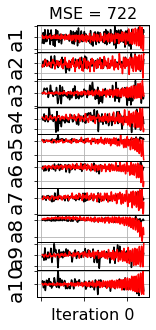

[722.1768977200175, 723.0249594402947, 723.0539376936734, 723.0053520658741, 722.9908336057665]


FileNotFoundError: [Errno 2] No such file or directory: 'coupled_data/200_time_modes_true2'

In [14]:
h1=np.loadtxt('h_200_new.txt')

normalized_h_store=h1
h_sub=np.array(h1)
thetas = np.linspace(0, 2 * np.pi, len(h1[0]))
ti=0
T_sim=1200
t_sim_display=0
choose_model=2
reduce=1
order=2
mode=10
max_height=1
coeffecients,feature_names,Q_sim,Q_real,t_test,x_train,x_sim,x_true,x, S2, Vh,MSE_i=find_model(h_sub,thetas,ti,order,mode,max_height,T_sim, t_sim_display,choose_model,"200",reduce)



In [ ]:
####     Save Data ####

n = 200
f = 10
np.savetxt(f'coeffs_sindy/sindy_coeff_matrix_{n}{f}.txt', coeffecients, fmt='%.2f')
np.savetxt(f'mode_hist/Qtrue_{n}{f}.txt', Q_real, fmt='%.2f')
np.savetxt(f'mode_hist/Qsim_{n}{f}.txt', Q_sim, fmt='%.2f')
np.savetxt(f'coeffs_sindy/sindy_sim_{n}{f}.txt', x_sim, fmt='%.2f')
np.savetxt(f'coeffs_sindy/sindy_true_{n}{f}.txt', x_true, fmt='%.2f')

### Analyse Data: ###

In [9]:
os.makedirs('mode_hist', exist_ok=True)
ST = 200
f = 10
x_real = np.loadtxt(f'coeffs_sindy/sindy_true_{ST}{f}.txt', dtype=float)
x_sim = np.loadtxt(f'coeffs_sindy/sindy_sim_{ST}{f}.txt', dtype=float)
n_plots = 10
cols = 2
rows = 5

fig, axs = plt.subplots(rows, cols, figsize=(2.7 * cols, 0.9 * rows))
axs = axs.flatten()

t_cut = 1000
x_sim_mod = []
for n in range(n_plots):
    t = np.arange(0, len(x_real[:t_cut, n]), 1)
    scale = 1 if n == 2 else 0.7
    axs[n].plot(t, x_real[:t_cut, n], linewidth=0.7, color='black', label='x_real')
    axs[n].plot(t, scale * x_sim[:t_cut, n], linewidth=0.7, color='red', label='x_sim')
    x_sim_mod.append(scale * x_sim[:t_cut, n])

    if n >= 8:  # Bottom row
        axs[n].set_xlabel('$t$', fontproperties=helvetica)
        axs[n].tick_params(axis='x', labelbottom=True)
        for label in axs[n].get_xticklabels():
            label.set_fontproperties(helvetica)
    else:
        axs[n].set_xticklabels([])
        axs[n].tick_params(axis='x', labelbottom=False)

    axs[n].set_ylabel(f'$q_{{{n+1}}}$', fontproperties=helvetica)
    for label in axs[n].get_yticklabels():
        label.set_fontproperties(helvetica)
    axs[n].set_yticks([-1, 0, 1])

for i in range(n_plots, rows * cols):
    fig.delaxes(axs[i])

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.savefig('mode_hist/sindy_modes.png', dpi=500)
plt.show()

FileNotFoundError: coeffs_sindy/sindy_true_20010.txt not found.

In [8]:
Q_sim = np.loadtxt(f'mode_hist/Qsim_{ST}{f}.txt', dtype=float)
Q_real = np.loadtxt(f'mode_hist/Qtrue_{ST}{f}.txt', dtype=float)
(x_range, kde_original_vals, kde_predict_vals,
 error_mae, kl_divergence, error_kde_mse,
 gam_original, gam_predict) = calc_deformation(Q_sim + 500, Q_real + 500)

plt.figure(figsize=(10, 5))
plt.plot(gam_original, label='Original Deformation')
plt.plot(gam_predict, label='Predicted Deformation')
plt.legend()
plt.show()

plt.figure(figsize=(5, 5))
plt.plot(x_range, kde_original_vals, label='Original Deformation KDE')
plt.plot(x_range, kde_predict_vals, label='Predicted Deformation KDE')
plt.xlim(-0.01, 0.1)
plt.legend()
plt.show()

NameError: name 'f' is not defined

/tmp/ipykernel_451989/2214557280.py:21: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. This has been deprecated since 3.3 and in 3.6, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = mpl.cm.get_cmap("PiYG").copy()
  cmap.set_bad(color='white')


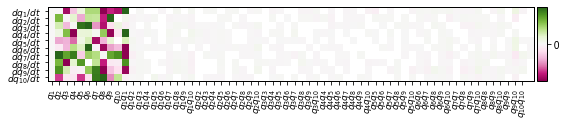

(10, 66)


In [6]:
### Plot SINDy coefficient matrix ###

ST = 200
coeffs = np.loadtxt(f'coeffs_sindy/sindy_coeff_matrix_{ST}.txt', dtype=float)

labels_y = [f'$dq_{{{i}}}/dt$' for i in range(1, 11)]

num_x = coeffs.shape[1]
labels_x = [f'$q_{{{i+1}}}$' for i in range(min(num_x, 10))]
count = 10
for i in range(1, 11):
    for j in range(i, 11):
        if count >= num_x:
            break
        labels_x.append(f'$q_{{{i}}}q_{{{j}}}$')
        count += 1
    if count >= num_x:
        break

cmap = plt.cm.PiYG
cmap.set_bad(color='white')
coeffs_masked = np.ma.masked_where(coeffs == 0, coeffs)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(coeffs_masked, cmap=cmap, vmin=-500, vmax=500)

ax.set_yticks(np.arange(len(labels_y)))
ax.set_yticklabels(labels_y, fontsize=9, fontproperties=helvetica)
ax.set_xticks(np.arange(len(labels_x)))
ax.set_xticklabels(labels_x, rotation=90, fontsize=9, fontproperties=helvetica)

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='2%', pad=0.05)
cbar = fig.colorbar(im, cax=cax)
cbar.set_ticks([-700, 0, 700])
cbar.set_ticklabels(['-1000', '0', '1000'])
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.tight_layout()
plt.savefig(f'mode_hist/coeffs_{ST}', dpi=500)
plt.show()
print(coeffs.shape)

In [11]:
U,S,V=np.linalg.svd(h_sub[10000:,:].T)

In [19]:
Ur=U[:,:10]
Sr=np.diag(S[:10])
Vr=x_sim.T
Vr_sim=x_true.T

H_recon=Ur@Sr@Vr
H_recon_sim=Ur@Sr@Vr_sim

n=200
np.savetxt(f'coeffs_sindy/sindy2_real_Q_{n}3.txt', H_recon, fmt='%.2f')
np.savetxt(f'coeffs_sindy/sindy2_sim_Q_{n}3.txt', H_recon_sim, fmt='%.2f')

### Calculate KL Divergenc  per mode ###


In [10]:
def calc_deformation_kl(Q_sim, Q_real, n_steps=500):
    """Wrapper around calc_deformation that returns only KL divergence."""
    (_, _, _, _, kl_divergence, _, _, _) = calc_deformation(
        Q_sim, Q_real, n_steps=n_steps, offset_correct=True
    )
    return kl_divergence

In [15]:
T_sim = 500
t_sim_display = 0
choose_model = 3
reduce = 1
order = 2
max_height = 1
error_list = []
thetas=np.linspace(0,2*np.pi,150)
for mode in range(2, 12):
    ti = 0
    coeffecients, feature_names, Q_sim, Q_real, t_test, x_train, x_sim, x_true, x, S2, Vh, MSE_i = \
        find_model(h_sub, thetas, ti, order, mode, max_height,
                   T_sim, t_sim_display, choose_model, "200", reduce)
    error = calc_deformation_kl(Q_sim+ 300, Q_real + 300, n_steps=500)
    error_list.append(error)

np.savetxt(f'deformation_error_{ST}.txt', error_list, fmt='%.6f')

training set: 8000
lent 8500


ValueError: operands could not be broadcast together with shapes (1000,) (150,) 

In [ ]:
error_final=[]
for degree in range(0,2):
    degree_error=[]
    for mode_i in range(0,12):
        
        error_mode=(np.abs(error_all[degree][mode_i]))
        degree_error.append(error_mode)
    error_final.append(degree_error)
        
error_final=np.array(error_final)
    
#np.savetxt('mode_hist/error_all_MSE.txt',error_final, fmt='%.4f', delimiter='\t')

NameError: name 'error_all' is not defined

In [32]:
# Find the index of the minimum value
min_index_flat = np.argmin(error_final)  # Index in flattened array
min_index_2d = np.unravel_index(min_index_flat, error_final.shape)  # Convert to 2D index

print("Minimum value:", error_final[min_index_2d])
print("Index of minimum value:", min_index_2d)


Minimum value: 135.76789754833982
Index of minimum value: (1, 11)


[6.423943379702523, 0.3629754855150488, 1.067877510440438, 1.2496325675948357, 1117007.2749004515, 4.619412977104122, 6.78384894004679, 0.3970246060761808, 0.018193472786277278, 0.17935330389934365, 1.156338189442831, 1.3538933031465736, 0.9968619632450653]


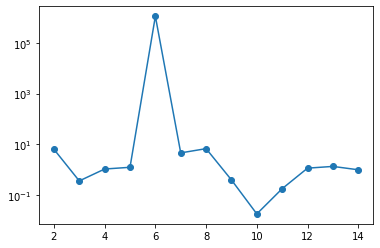

In [7]:
mse=[np.abs(np.mean(error_j[1:])) for error_j in error ]
print(mse)
modes=np.arange(2,len(mse)+2)
plt.plot(modes,mse,'-o')
plt.yscale('log')

findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.


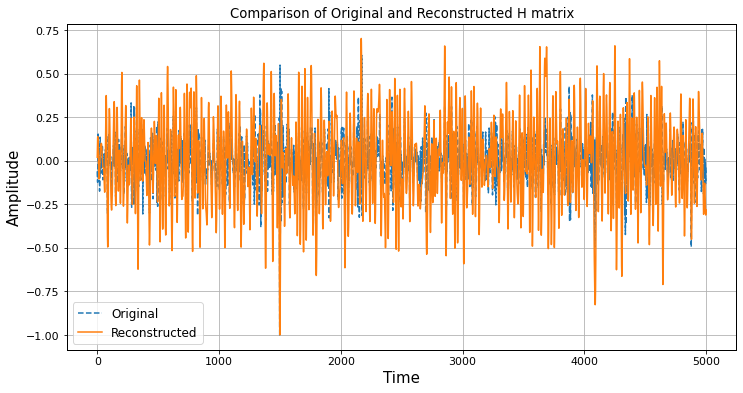

In [12]:
# Load the height field data
h1 = np.loadtxt('h_200.txt')

# Apply POD (SVD decomposition)
U, S, Vt = np.linalg.svd(h1.T, full_matrices=False)

# Number of modes to keep
r = 10  # Adjust this based on your needs

# Truncate to r modes
Ur = U[:, :r]
Sr = np.diag(S[:r])
Vtr = Vt[:r, :]

# Apply Fourier truncation to temporal modes
# Vtr has shape (r, time_points), need to transpose for fourier_lowest_modes_matrix
Vtr_truncated, spare = fourier_lowest_modes_matrix(Vtr.T, num_modes=2000)
Vtr_truncated = Vtr_truncated.T  # Transpose back to (r, time_points)




# Reconstruct the H matrix with truncated temporal modes
h1_reconstructed = Ur @ Sr @ Vtr_truncated
h1_reconstructed=h1_reconstructed.T
plt.figure(figsize=(12, 6))
plt.plot(h1[:5000,10]/np.max(np.abs(h1[:5000,10])), label='Original', linestyle='dashed')
plt.plot(h1_reconstructed[:5000,10]/np.max(np.abs(h1_reconstructed[:5000,10])), label='Reconstructed')
plt.title('Comparison of Original and Reconstructed H matrix')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()
np.savetxt(f"h_200_new.txt", h1_reconstructed, fmt='%.6f')